In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from imblearn.under_sampling import RandomUnderSampler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import pickle
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('yield_dataset/crop_yield.csv')
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [3]:
df.shape

(1000000, 10)

In [4]:
df.drop(df[df['Crop'] == 'Barley'].index, inplace=True)
df.shape

(833223, 10)

## Pre-Processing

Missing and Duplicate Values

In [5]:
df = df.dropna()
df = df.drop_duplicates()
df.shape

(833223, 10)

Converting Boolean columns to numerical

In [6]:
boolean_cols = ['Fertilizer_Used', 'Irrigation_Used']
for col in boolean_cols:
    if df[col].dtype == 'object' or df[col].dtype == 'bool':
        df[col] = df[col].map({'Yes': 1, 'No': 0, True: 1, False: 0, 'yes': 1, 'no': 0})
        df[col] = df[col].fillna(0).astype(int)

df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,0,1,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,1,1,Rainy,140,8.527341
3,North,Sandy,Soybean,986.866331,16.644190,0,1,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,1,1,Cloudy,110,7.248251
5,South,Silt,Soybean,797.471182,37.704974,0,1,Rainy,74,5.898416


Converting categorical columns to numerical

In [7]:
categorical_cols = ['Region', 'Soil_Type', 'Crop', 'Weather_Condition']
target_encodings = {}

for col in categorical_cols:
    if col in df.columns:
        encoding = df.groupby(col)['Yield_tons_per_hectare'].mean().to_dict()
        target_encodings[col] = encoding
        df[col + '_encoded'] = df[col].map(encoding)
        print(f"{col} encoding: {encoding}")

Region encoding: {'East': 4.6452208413583085, 'North': 4.65323104119146, 'South': 4.649300168363309, 'West': 4.651781630778917}
Soil_Type encoding: {'Chalky': 4.653482689539295, 'Clay': 4.643510578961214, 'Loam': 4.652648386671746, 'Peaty': 4.651265592566658, 'Sandy': 4.646436273950509, 'Silt': 4.651967275137793}
Crop encoding: {'Cotton': 4.650840828805868, 'Maize': 4.641387423472833, 'Rice': 4.650760070266093, 'Soybean': 4.653711610110017, 'Wheat': 4.6527401460100135}
Weather_Condition encoding: {'Cloudy': 4.645800269010232, 'Rainy': 4.653424869308325, 'Sunny': 4.650422041671514}


In [8]:
df = df.drop(columns=categorical_cols)

In [9]:
rename_dict = {col + '_encoded': col for col in categorical_cols}
df = df.rename(columns=rename_dict)

In [10]:
df.head()

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare,Region,Soil_Type,Crop,Weather_Condition
0,897.077239,27.676966,0,1,122,6.555816,4.651782,4.646436,4.650841,4.645800
1,992.673282,18.026142,1,1,140,8.527341,4.649300,4.643511,4.650760,4.653425
3,986.866331,16.644190,0,1,146,6.517573,4.653231,4.646436,4.653712,4.653425
4,730.379174,31.620687,1,1,110,7.248251,4.649300,4.651967,4.652740,4.645800
5,797.471182,37.704974,0,1,74,5.898416,4.649300,4.651967,4.653712,4.653425


In [11]:
df.shape

(833223, 10)

In [12]:
df.describe()

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare,Region,Soil_Type,Crop,Weather_Condition
count,833223.000000,833223.000000,833223.000000,833223.000000,833223.000000,833223.000000,833223.000000,833223.000000,833223.000000,833223.000000
mean,550.066118,27.505781,0.500076,0.499488,104.508912,4.649885,4.649885,4.649885,4.649885,4.649885
std,259.868267,7.221124,0.500000,0.500000,25.962721,1.696228,0.003036,0.003636,0.004399,0.003134
min,100.005750,15.000068,0.000000,0.000000,60.000000,-1.147613,4.645221,4.643511,4.641387,4.645800
25%,325.059847,21.253312,0.000000,0.000000,82.000000,3.419927,4.649300,4.646436,4.650760,4.645800
50%,550.188354,27.512674,1.000000,0.000000,105.000000,4.652047,4.651782,4.651967,4.650841,4.650422
75%,774.853691,33.749848,1.000000,1.000000,127.000000,5.878641,4.653231,4.652648,4.652740,4.653425
max,999.998098,39.999997,1.000000,1.000000,149.000000,9.963372,4.653231,4.653483,4.653712,4.653425


<Axes: >

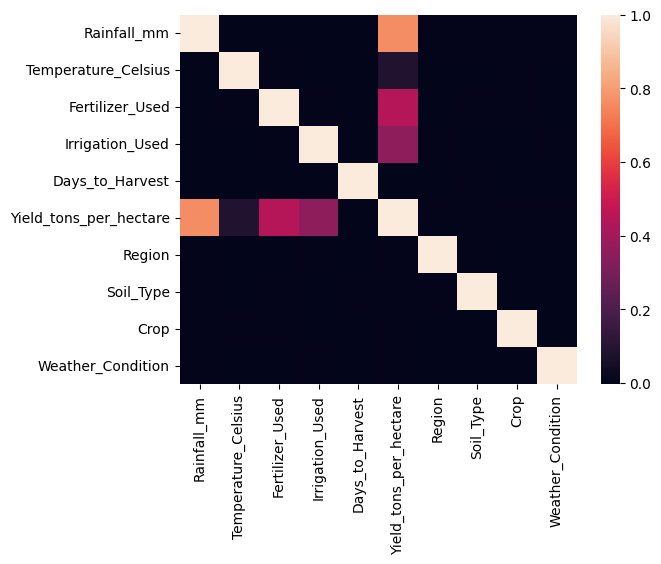

In [13]:
sns.heatmap(df.corr())

From the correlation graph, we can drop the columns that have low impact on final yield

In [14]:
selected_features = ['Crop', 'Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used']

In [15]:
X = df[selected_features].values
y = df['Yield_tons_per_hectare'].values

In [16]:
X, y

(array([[  4.65084083, 897.07723911,  27.67696637,   0.        ,
           1.        ],
        [  4.65076007, 992.67328162,  18.02614225,   1.        ,
           1.        ],
        [  4.65371161, 986.86633134,  16.64419019,   0.        ,
           1.        ],
        ...,
        [  4.65084083, 867.36204622,  24.37004189,   1.        ,
           0.        ],
        [  4.65274015, 492.81285654,  33.04550506,   0.        ,
           0.        ],
        [  4.64138742, 180.93618014,  27.29884735,   1.        ,
           0.        ]], shape=(833223, 5)),
 array([6.55581626, 8.52734091, 6.51757251, ..., 5.76318192, 2.07015871,
        2.93724319], shape=(833223,)))

Since our Dataset is too large, we need to downsample it

In [17]:
y_binned = pd.cut(y, bins=5, labels=False)

In [18]:
np.bincount(y_binned)

array([ 10208, 180158, 378576, 237332,  26949])

In [19]:
rus = RandomUnderSampler(random_state=42)
X_resampled, y_binned_resampled = rus.fit_resample(X, y_binned)

In [20]:
resampled_indices = rus.sample_indices_
y_resampled = y[resampled_indices]

In [21]:
np.bincount(y_binned_resampled)

array([10208, 10208, 10208, 10208, 10208])

In [22]:
X_resampled.shape

(51040, 5)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

In [30]:
X[:,1]

array([897.07723911, 992.67328162, 986.86633134, ..., 867.36204622,
       492.81285654, 180.93618014], shape=(833223,))

### Scaling data

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

In [28]:
X_train_lstm.shape, X_test_lstm.shape

((40832, 1, 5), (10208, 1, 5))

## Modelling

In [33]:
model = Sequential([
    LSTM(32, activation='relu', input_shape=(1, len(selected_features)), return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

In [34]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,409 (21.13 KB)

 Trainable params: 5,409 (21.13 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_lstm, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
1021/1021 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3.2125 - mae: 1.0737 - val_loss: 0.2849 - val_mae: 0.4203
Epoch 2/50
1021/1021 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4763 - mae: 0.5332 - val_loss: 0.2508 - val_mae: 0.3903
Epoch 3/50
1021/1021 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4079 - mae: 0.4962 - val_loss: 0.2573 - val_mae: 0.3979
Epoch 4/50
1021/1021 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3734 - mae: 0.4735 - val_loss: 0.2498 - val_mae: 0.3942
Epoch 5/50
1021/1021 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3449 - mae: 0.4589 - val_loss: 0.2671 - val_mae: 0.4137
Epoch 6/50
1021/1021 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3181 - mae: 0.4402 - val_loss: 0.2742 - val_mae: 0.4179
Epoch 7/50
1021/1021 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2982 - mae: 0.4257 - val_loss: 0.2965 - val_mae: 0.4350
Epoch 8/50
1021/1021 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2850 - mae: 0.4161 - val_loss: 0.3752 - val_mae: 0.5005
Epoch 9/50
1021/1021 ━━━━━━━━━━━━━━━━━━━

## Evaluation

In [36]:
y_pred = model.predict(X_test_lstm).flatten()

319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step


In [37]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [38]:
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

RMSE: 0.5051
MAE: 0.3997
R² Score: 0.9656


## Visualization

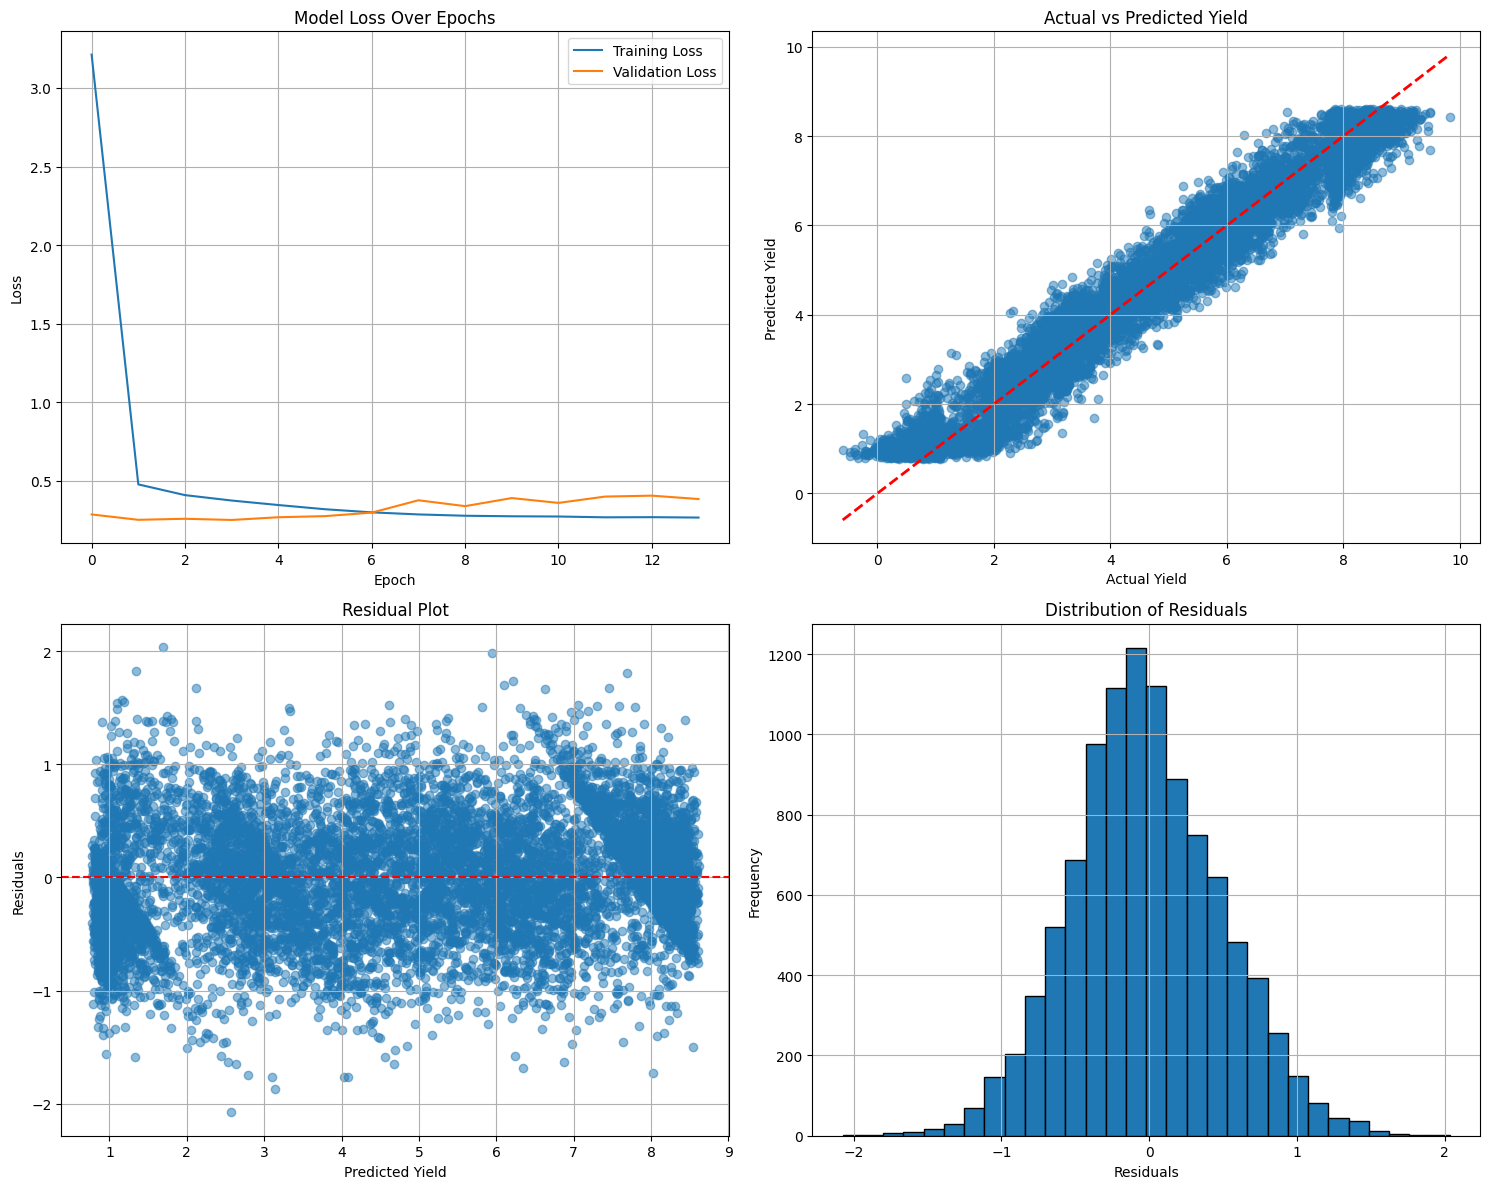

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Training history
axes[0, 0].plot(history.history['loss'], label='Training Loss')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('Model Loss Over Epochs')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Actual vs Predicted
axes[0, 1].scatter(y_test, y_pred, alpha=0.5)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_title('Actual vs Predicted Yield')
axes[0, 1].set_xlabel('Actual Yield')
axes[0, 1].set_ylabel('Predicted Yield')
axes[0, 1].grid(True)

# Residuals
residuals = y_test - y_pred
axes[1, 0].scatter(y_pred, residuals, alpha=0.5)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_title('Residual Plot')
axes[1, 0].set_xlabel('Predicted Yield')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].grid(True)

# Error distribution
axes[1, 1].hist(residuals, bins=30, edgecolor='black')
axes[1, 1].set_title('Distribution of Residuals')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()


## Feature Importance

In [40]:
baseline_score = r2_score(y_test, y_pred)
importance_scores = []

for i, feature in enumerate(selected_features):
    X_test_permuted = X_test_lstm.copy()
    np.random.shuffle(X_test_permuted[:, 0, i])
    y_pred_permuted = model.predict(X_test_permuted, verbose=0).flatten()
    permuted_score = r2_score(y_test, y_pred_permuted)
    importance = baseline_score - permuted_score
    importance_scores.append(importance)
    print(f"{feature}: {importance:.4f}")


Crop: -0.0000
Rainfall_mm: 0.7954
Temperature_Celsius: 0.0052
Fertilizer_Used: 0.1912
Irrigation_Used: 0.1274


# Saving model

In [46]:
import joblib

In [41]:
weights = []
for layer in model.layers:
    weights.append(layer.get_weights())


In [44]:
model_artifacts = {
    'weights': weights,
    'scaler_mean': scaler.mean_,
    'scaler_scale': scaler.scale_,
    'selected_features': selected_features,
    'target_encodings': target_encodings,
    'model_config': {
        'input_shape': (1, len(selected_features)),
        'architecture': [
            {'type': 'LSTM', 'units': 32, 'activation': 'relu'},
            {'type': 'Dropout', 'rate': 0.2},
            {'type': 'Dense', 'units': 16, 'activation': 'relu'},
            {'type': 'Dense', 'units': 1}
        ]
    }
}

In [45]:
class YieldPredictor:
    """Complete pipeline for crop yield prediction"""
    
    def __init__(self, artifacts):
        self.weights = artifacts['weights']
        self.scaler_mean = artifacts['scaler_mean']
        self.scaler_scale = artifacts['scaler_scale']
        self.selected_features = artifacts['selected_features']
        self.target_encodings = artifacts['target_encodings']
    
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def relu(self, x):
        return np.maximum(0, x)
    
    def tanh_activation(self, x):
        return np.tanh(x)
    
    def lstm_cell(self, x, Wf, Uf, bf, Wi, Ui, bi, Wc, Uc, bc, Wo, Uo, bo, h_prev, c_prev):
        """LSTM cell forward pass"""
        f = self.sigmoid(np.dot(x, Wf) + np.dot(h_prev, Uf) + bf)
        i = self.sigmoid(np.dot(x, Wi) + np.dot(h_prev, Ui) + bi)
        c_candidate = self.tanh_activation(np.dot(x, Wc) + np.dot(h_prev, Uc) + bc)
        c = f * c_prev + i * c_candidate
        o = self.sigmoid(np.dot(x, Wo) + np.dot(h_prev, Uo) + bo)
        h = o * self.tanh_activation(c)
        return h, c
    
    def encode_categorical(self, crop, region=None, soil_type=None, weather=None):
        """Encode categorical variables using target encoding"""
        crop_encoded = self.target_encodings['Crop'].get(crop, np.mean(list(self.target_encodings['Crop'].values())))
        return crop_encoded
    
    def predict(self, crop, rainfall, temperature, fertilizer, irrigation):
        """
        Predict crop yield
        
        Parameters:
        - crop: str (crop name, e.g., 'Wheat', 'Rice', 'Corn')
        - rainfall: float (rainfall in mm)
        - temperature: float (temperature in Celsius)
        - fertilizer: bool or int (True/False or 1/0)
        - irrigation: bool or int (True/False or 1/0)
        
        Returns:
        - predicted yield in tons per hectare
        """
        # Encode crop
        crop_encoded = self.encode_categorical(crop)
        
        # Convert boolean to int
        fertilizer = int(fertilizer)
        irrigation = int(irrigation)
        
        # Prepare input
        input_data = np.array([[crop_encoded, rainfall, temperature, fertilizer, irrigation]])
        
        # Scale input
        input_scaled = (input_data - self.scaler_mean) / self.scaler_scale
        
        # LSTM layer
        lstm_weights = self.weights[0]
        W, U, b = lstm_weights[0], lstm_weights[1], lstm_weights[2]
        
        units = 32
        Wi, Wf, Wc, Wo = np.split(W, 4, axis=1)
        Ui, Uf, Uc, Uo = np.split(U, 4, axis=1)
        bi, bf, bc, bo = np.split(b, 4)
        
        h = np.zeros((1, units))
        c = np.zeros((1, units))
        
        h, c = self.lstm_cell(input_scaled, Wf, Uf, bf, Wi, Ui, bi, Wc, Uc, bc, Wo, Uo, bo, h, c)
        
        # Dense layer 1
        W1, b1 = self.weights[2][0], self.weights[2][1]
        hidden = self.relu(np.dot(h, W1) + b1)
        
        # Dense layer 2
        W2, b2 = self.weights[3][0], self.weights[3][1]
        output = np.dot(hidden, W2) + b2
        
        return float(output[0, 0])


In [47]:
predictor = YieldPredictor(model_artifacts)
joblib.dump(predictor, 'crop_yield_pipeline.pkl')

['crop_yield_pipeline.pkl']

## Predicting

In [48]:
pipeline = joblib.load('crop_yield_pipeline.pkl')

In [49]:
crop = "Wheat"
rainfall = 800
temperature = 25
fertilizer = 1
irrigation = 1

predicted_yield = pipeline.predict(crop, rainfall, temperature, fertilizer, irrigation)
print(f"Predicted Yield for {crop}: {predicted_yield:.2f} tons/hectare")

Predicted Yield for Wheat: 6.76 tons/hectare
